In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torch
from torchvision.ops import batched_nms
from ultralytics import YOLO
import ultralytics

In [2]:
predictions = [
    {"id": "A", "box": [0, 0, 100, 100],     "score": 0.95, "class_id": 0},
    {"id": "B", "box": [5, 5, 105, 105],     "score": 0.90, "class_id": 0},
    {"id": "C", "box": [200, 0, 300, 100],   "score": 0.80, "class_id": 0},
    {"id": "D", "box": [0, 0, 100, 100],     "score": 0.75, "class_id": 1},
    {"id": "E", "box": [400, 0, 500, 100],   "score": 0.20, "class_id": 0},
    {"id": "F", "box": [600, 0, 700, 100],   "score": 0.60, "class_id": 0},
]

CONF_THRESHOLD = 0.25

filtered = [
    p for p in predictions
    if p["score"] >= CONF_THRESHOLD
]

print("After confidence filter:", [p["id"] for p in filtered])

After confidence filter: ['A', 'B', 'C', 'D', 'F']


In [3]:
def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    
    inter_w = max(0, min(ax2, bx2) - max(ax1, bx1))
    inter_h = max(0, min(ay2, by2) - max(ay1, by1))
    intersection = inter_w * inter_h

    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    union = area_a + area_b - intersection

    return intersection / union if union > 0 else 0.0

print(round(iou_xyxy(
    predictions[0]["box"],
    predictions[1]["box"]
), 4))

0.8223


**Implement NMS manually**

In [4]:
def manual_nms(predictions, iou_threshold=0.5, class_aware=True):
    remaining = sorted(
        predictions,
        key=lambda p: p["score"],
        reverse=True
    )
    kept = []
    
    while remaining:
        best = remaining.pop(0)
        kept.append(best)
        
        survivors = []
        for candidate in remaining:
            compare = (
                not class_aware
                or candidate["class_id"] == best["class_id"]
            )
            
            overlap = iou_xyxy(best["box"], candidate["box"])
            if not (compare and overlap > iou_threshold):
                survivors.append(candidate)
        
        remaining = survivors
    
    return kept

In [5]:
kept = manual_nms(filtered, iou_threshold=0.5)
agnostic_kept = manual_nms(
    filtered,
    iou_threshold=0.5,
    class_aware=False
)

print("Class-aware   :", [p["id"] for p in kept])
print("Class-agnostic:", [p["id"] for p in agnostic_kept])

Class-aware   : ['A', 'C', 'D', 'F']
Class-agnostic: ['A', 'C', 'F']


In [6]:
for threshold in [0.3, 0.5, 0.9]:
    result = manual_nms(
        filtered,
        iou_threshold=threshold
    )
    print(threshold, [p["id"] for p in result])

0.3 ['A', 'C', 'D', 'F']
0.5 ['A', 'C', 'D', 'F']
0.9 ['A', 'B', 'C', 'D', 'F']


**Before/after visualization**

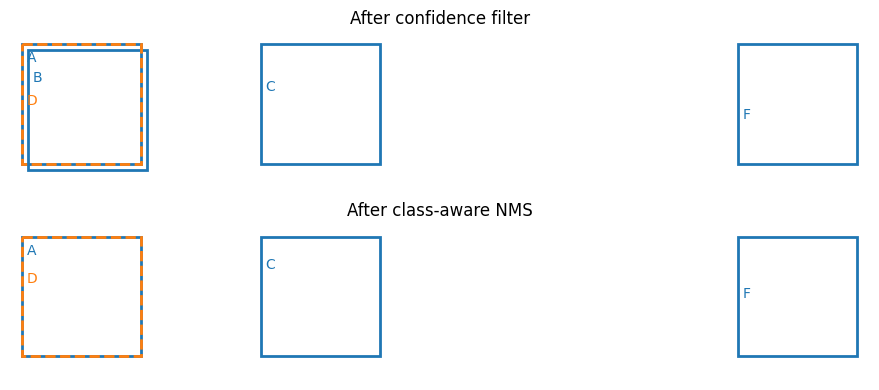

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 4))

for ax, items, title in zip(
    axes, [filtered, kept], ["After confidence filter", "After class-aware NMS"]
):
    for i, p in enumerate(items):
        x1, y1, x2, y2 = p["box"]
        color = "tab:blue" if p["class_id"] == 0 else "tab:orange"
        style = "-" if p["class_id"] == 0 else "--"
        
        ax.add_patch(Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor=color,
            linestyle=style, linewidth=2,
        ))
        ax.text(x1 + 4, y1 + 15 + i * 12, p["id"], color=color)

    ax.set(
        xlim=(-10, 710), ylim=(120, -10),
        aspect="equal", title=title,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

**Verify using torchVision**

In [8]:
boxes =  torch.tensor(
    [p["box"] for p in filtered],
    dtype=torch.float32
).reshape(-1, 4)

scores = torch.tensor(
    [p["score"] for p in filtered],
    dtype=torch.float32,
)

class_ids = torch.tensor(
    [p["class_id"] for p in filtered],
    dtype=torch.int64,
)

indices = batched_nms(boxes, scores, class_ids, 0.5)
library_ids = [filtered[i]["id"] for i in indices.tolist()]

print("TorchVision:", library_ids)

TorchVision: ['A', 'C', 'D', 'F']


**Ground truth and matcher**

In [10]:
ground_truth = [
    {"id": "G1", "box": [0, 0, 100, 100],   "class_id": 0},
    {"id": "G2", "box": [200, 0, 300, 100], "class_id": 0},
    {"id": "G3", "box": [400, 0, 500, 100], "class_id": 0},
]

def match_predictions(predictions, ground_truth, iou_threshold=0.5):
    match_gt = set()
    decisions = []
    
    for prediction in sorted(
        predictions, key=lambda p: p["score"], reverse=True
    ):
        candidate = [
            j for j, target in enumerate(ground_truth)
            if j not in match_gt
            and target["class_id"] == prediction["class_id"]
        ]
        
        best = max(candidate, 
                   key=lambda j: iou_xyxy(
                       prediction["box"], ground_truth[j]["box"]
                   ),
                   default=None
            )

        if best is not None and iou_xyxy(
            prediction["box"], ground_truth[best]["box"]
        ) >= iou_threshold:
            match_gt.add(best)
            decisions.append((
                prediction["id"], "TP", ground_truth[best]["id"]
            ))
        else:
            decisions.append((prediction["id"], "FP", None))

    missed = [
        g["id"] for j, g in enumerate(ground_truth)
        if j not in match_gt
    ]
    return decisions, missed